#  Building Permits — Feature Engineering, EDA & Modelling (XGBoost v2)

**Goal:** Transform two raw permit CSVs into a clean, model-ready dataset, uncover patterns in permit approval times, and train an XGBoost model with a fixed `PredefinedSplit` to eliminate data leakage in hyperparameter search.



## 1 · Imports

All libraries used across data wrangling, statistical testing, visualisation, and machine learning. Note `xgboost` replaces `lightgbm` as the primary model in this version.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import xgboost as xgb
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb

## 2 · Load Raw Data

Two separate CSV exports from the City of Toronto open data portal:
- `permits_new.csv` — recent extract
- `permits_old.csv` — legacy extract

Both use ISO-8859-1 encoding, which is standard for this portal.

In [ ]:
df_old = pd.read_csv(r'data/permits_old.csv', low_memory=False, encoding='ISO-8859-1')
df_new = pd.read_csv(r'data/permits_new.csv', low_memory=False, encoding='ISO-8859-1')
pd.set_option('display.max_columns', None)
print(df_new.head())
print(df_old.head())

   _id     PERMIT_NUM REVISION_NUM             PERMIT_TYPE  \
0    1  19 146184 DRN           00  Drain and Site Service   
1    2  19 176553 DRN           00  Drain and Site Service   
2    3  19 176561 DRN           00  Drain and Site Service   
3    4  19 160209 DRN           00  Drain and Site Service   
4    5  19 160397 DRN           00  Drain and Site Service   

        STRUCTURE_TYPE                          WORK STREET_NUM STREET_NAME  \
0  SFD - Semi-Detached  Building Permit Related (DR)         11      FULTON   
1       SFD - Detached  Building Permit Related (DR)          6     ARDMORE   
2       SFD - Detached  Building Permit Related (DR)         92   DUNINGTON   
3       SFD - Detached  Building Permit Related (DR)         96    WANSTEAD   
4       SFD - Detached  Building Permit Related (DR)        392     DOUGLAS   

  STREET_TYPE STREET_DIRECTION POSTAL     GEO_ID WARD_GRID APPLICATION_DATE  \
0         AVE                     M4K   806715.0     S1424       2019-04-

## 3 · Data Quality Check — Float Columns

Before dropping or converting anything, we inspect every `float64` column in `df_new` for null values and zero counts. This informs which columns are safe to convert to integers and which may need to be dropped.

In [ ]:
float_cols = df_new.select_dtypes(include=['float64']).columns
for col in float_cols:
    print(f"Column: {col}")
    print("Null values:", df_new[col].isnull().sum())
    print("NaN values:", df_new[col].isna().sum())
    print("Zero values:", (df_new[col] == 0).sum())
    print("\n")

Column: GEO_ID
Null values: 7230
NaN values: 7230
Zero values: 0


Column: DWELLING_UNITS_CREATED
Null values: 242462
NaN values: 242462
Zero values: 109743


Column: DWELLING_UNITS_LOST
Null values: 242787
NaN values: 242787
Zero values: 123690


Column: ASSEMBLY
Null values: 0
NaN values: 0
Zero values: 374381


Column: INSTITUTIONAL
Null values: 0
NaN values: 0
Zero values: 375130


Column: RESIDENTIAL
Null values: 0
NaN values: 0
Zero values: 342748


Column: BUSINESS_AND_PERSONAL_SERVICES
Null values: 0
NaN values: 0
Zero values: 374653


Column: MERCANTILE
Null values: 0
NaN values: 0
Zero values: 374574


Column: INDUSTRIAL
Null values: 0
NaN values: 0
Zero values: 374152


Column: INTERIOR_ALTERATIONS
Null values: 1
NaN values: 1
Zero values: 320457


Column: DEMOLITION
Null values: 0
NaN values: 0
Zero values: 363589




## 4 · Drop Irrelevant Columns

Remove columns that carry no analytical value:
- `df_new` loses `_id`, `BUILDER_NAME`, `DEMOLITION`, and all street-address fields
- `df_old` loses only the street-address fields (the others don't exist there)

Street address columns are dropped because geographic analysis will use `ward_grid` and `postal` instead, which are cleaner and more consistent across both datasets.

In [ ]:
df_new = df_new.drop(columns=['_id', 'BUILDER_NAME', 'DEMOLITION', 'STREET_DIRECTION', 'STREET_NUM', 'STREET_NAME', 'STREET_TYPE'])
df_old = df_old.drop(columns=['STREET_DIRECTION', 'STREET_NUM', 'STREET_NAME', 'STREET_TYPE'])
print(df_new.info())
print(df_old.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375163 entries, 0 to 375162
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   PERMIT_NUM                      375163 non-null  object 
 1   REVISION_NUM                    375163 non-null  object 
 2   PERMIT_TYPE                     375163 non-null  object 
 3   STRUCTURE_TYPE                  373084 non-null  object 
 4   WORK                            375108 non-null  object 
 5   POSTAL                          375163 non-null  object 
 6   GEO_ID                          367933 non-null  float64
 7   WARD_GRID                       375158 non-null  object 
 8   APPLICATION_DATE                375157 non-null  object 
 9   ISSUED_DATE                     343994 non-null  object 
 10  COMPLETED_DATE                  375163 non-null  object 
 11  STATUS                          375163 non-null  object 
 12  DESCRIPTION     

## 5 · Normalise Column Names

Lowercase all column names so both dataframes share a consistent naming convention before we merge them. Without this, `APPLICATION_DATE` and `application_date` would be treated as different columns during the combine step.

In [ ]:
df_new.columns = df_new.columns.str.lower()
df_old.columns = df_old.columns.str.lower()
print(df_new.info())
print(df_old.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375163 entries, 0 to 375162
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   permit_num                      375163 non-null  object 
 1   revision_num                    375163 non-null  object 
 2   permit_type                     375163 non-null  object 
 3   structure_type                  373084 non-null  object 
 4   work                            375108 non-null  object 
 5   postal                          375163 non-null  object 
 6   geo_id                          367933 non-null  float64
 7   ward_grid                       375158 non-null  object 
 8   application_date                375157 non-null  object 
 9   issued_date                     343994 non-null  object 
 10  completed_date                  375163 non-null  object 
 11  status                          375163 non-null  object 
 12  description     

## 6 · Combine Datasets

Keep only the columns that exist in **both** files (intersection), then stack them with `pd.concat`. Using only common columns avoids NaN-filled columns from the dataset that didn't have them.

In [ ]:
#Combine the two datasets, keeping only the common columns
common_columns = list(set(df_new.columns) & set(df_old.columns))
df_permits = pd.concat([df_new[common_columns], df_old[common_columns]], ignore_index=True)
print(df_permits.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823256 entries, 0 to 823255
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   industrial                      823256 non-null  float64
 1   ward_grid                       823213 non-null  object 
 2   est_const_cost                  785024 non-null  object 
 3   proposed_use                    629472 non-null  object 
 4   interior_alterations            823255 non-null  float64
 5   institutional                   823256 non-null  float64
 6   geo_id                          794943 non-null  float64
 7   mercantile                      823256 non-null  float64
 8   issued_date                     775397 non-null  object 
 9   current_use                     625813 non-null  object 
 10  permit_type                     823256 non-null  object 
 11  revision_num                    823256 non-null  object 
 12  completed_date  

## 7 · Parse Dates

The three date columns contain two different formats:
- `2019-04-29` (new dataset)
- `2000-10-17 00:00:00.000` (old dataset)

Some entries also contain the garbage sentinel string `'DO NOT UPDATE OR DELETE THIS INFO FIELD'` instead of a date. `robust_date_parse` handles all three cases — mixed formats, sentinel strings, and string `'nan'` — coercing anything unparseable to `NaT`.

In [ ]:
# Function to safely parse your specific timestamp format
def robust_date_parse(series):
    # 1. Force to string and clean whitespace
    s = series.astype(str).str.strip()
    
    # 2. Remove the "Garbage" text if it exists here too
    s = s.replace("DO NOT UPDATE OR DELETE THIS INFO FIELD", pd.NA)
    s = s.replace('nan', pd.NA) # Handle string 'nan'
    
    # 3. Parse with explicit format (Much faster)
    # format='mixed' allows Pandas to handle both '2000-01-01' and '2000-01-01 12:00:00.000'
    return pd.to_datetime(s, format='mixed', errors='coerce')

# Apply to your columns
print("Parsing Dates...")
df_permits['application_date'] = robust_date_parse(df_permits['application_date'])
df_permits['issued_date'] = robust_date_parse(df_permits['issued_date'])
df_permits['completed_date'] = robust_date_parse(df_permits['completed_date'])

# Check the result
print(df_permits[['application_date', 'issued_date', 'completed_date']].info())
print(df_permits[['application_date', 'issued_date', 'completed_date']].head())

Parsing Dates...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823256 entries, 0 to 823255
Data columns (total 3 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   application_date  823217 non-null  datetime64[ns]
 1   issued_date       775397 non-null  datetime64[ns]
 2   completed_date    823256 non-null  datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 18.8 MB
None
  application_date issued_date completed_date
0       2019-04-29  2019-06-13     2020-04-14
1       2019-06-23  2019-07-09     2025-07-11
2       2019-06-23  2019-07-10     2020-07-14
3       2019-05-27  2019-07-09     2022-01-28
4       2019-05-27  2019-06-19     2021-01-11


## 8 · Checkpoint Save

Save the combined, date-parsed dataset to disk before continuing with cleaning. This means we don't have to re-run the merge and date parsing every time we open the notebook.

In [ ]:
#Checkpoint, save the combined dataset to a new CSV file
df_permits.to_csv('data/permits_combined.csv', index=False)

## 9 · Type Coercion — Flag Columns to Int

The binary flag columns (`assembly`, `residential`, `industrial`, etc.) were loaded as `float64` because of NaN values. We coerce them to numeric, fill NaN with `0`, and cast to `int`. `geo_id` is also cast here since it is an identifier, not a continuous value.

In [ ]:
#Convert numeric columns to integers, filling NaN with 0 and coercing errors to NaN before filling
cols_to_convert = ['interior_alterations', 'business_and_personal_services', 'assembly', 'mercantile', 'institutional', 'industrial', 'residential', 'geo_id']
for col in cols_to_convert:
    df_permits[col] = pd.to_numeric(df_permits[col], errors='coerce').fillna(0).astype(int)

## 10 · Drop Low-Value Columns

- `est_const_cost` — contains the garbage sentinel string throughout; not reliably parseable
- `dwelling_units_lost` — too sparse to be useful
- `work` and `description` — free-text fields; NLP is out of scope for this pipeline

In [ ]:
# Drop features that are not relevant to our analysis or have too many missing values
df_permits = df_permits.drop(columns=['est_const_cost','dwelling_units_lost', 'work', 'description'])

## 11 · Quality Check — Int Columns

After converting to integers, confirm there are no remaining nulls and get a sense of how sparse the flag columns are (expected: mostly zeros).

In [ ]:
#Check every column with int data type for null, nan and 0 values
int_cols = df_permits.select_dtypes(include=['int64']).columns
for col in int_cols:
    print(f"Column: {col}")
    print("Null values:", df_permits[col].isnull().sum())
    print("NaN values:", df_permits[col].isna().sum())
    print("Zero values:", (df_permits[col] == 0).sum())
    print("\n")

Column: industrial
Null values: 0
NaN values: 0
Zero values: 820978


Column: interior_alterations
Null values: 0
NaN values: 0
Zero values: 715328


Column: institutional
Null values: 0
NaN values: 0
Zero values: 822915


Column: geo_id
Null values: 0
NaN values: 0
Zero values: 28313


Column: mercantile
Null values: 0
NaN values: 0
Zero values: 820442


Column: residential
Null values: 0
NaN values: 0
Zero values: 737596


Column: assembly
Null values: 0
NaN values: 0
Zero values: 821655


Column: business_and_personal_services
Null values: 0
NaN values: 0
Zero values: 819455




## 12 · Quality Check — Date Nulls

Check how many records are missing each date after parsing. `issued_date` is expected to have the most nulls — permits that were applied for but never formally issued would have no issue date.

In [ ]:
#Check the date columns for null values

print("Null values in 'application_date':", df_permits['application_date'].isnull().sum())
print("Null values in 'issued_date':", df_permits['issued_date'].isnull().sum())
print("Null values in 'completed_date':", df_permits['completed_date'].isnull().sum())




Null values in 'application_date': 39
Null values in 'issued_date': 47859
Null values in 'completed_date': 0


## 13 · Explore `dwelling_units_created`

This column has mixed types across the two source files — some values are floats, some are strings. We inspect the value distribution before fixing it.

In [ ]:
#Check the distribution of feature 'dwelling_units_created'
(df_permits['dwelling_units_created'].value_counts(dropna=False))

dwelling_units_created
NaN    544805
0      117628
0.0    109743
1       25531
1.0     21352
        ...  
165         1
126         1
210         1
86          1
270         1
Name: count, Length: 594, dtype: int64

## 14 · Fix & Filter `dwelling_units_created`

Coerce to numeric (strings become NaN), fill NaN with `0`, cast to `int`, then drop any rows where the value is negative (data entry errors).

In [ ]:
df_permits['dwelling_units_created'] = pd.to_numeric(
	df_permits['dwelling_units_created'], errors='coerce'
).fillna(0).astype(int)

df_permits = df_permits[df_permits['dwelling_units_created'] >= 0]

## 15 · Categorical Cardinality Check

Understand how many unique values exist in each categorical column before deciding how to handle them. High cardinality columns (like `structure_type`) will need grouping; low cardinality ones (like `status`) can be used directly.

In [ ]:
#Check the unique values in categorical columns
print("Unique values in df_permits 'structure_type':")
print(df_permits['structure_type'].nunique())
print("Unique values in df_permits 'revision_num':")
print(df_permits['revision_num'].nunique())
print("\nUnique values in df_permits 'permit_type':")
print(df_permits['permit_type'].nunique())
print("\nUnique values in df_permits 'proposed_use':")
print(df_permits['proposed_use'].nunique())
print("\nUnique values in df_permits 'current_use':")
print(df_permits['current_use'].nunique())
print("\nUnique values in df_permits 'status':")
print(df_permits['status'].nunique())



Unique values in df_permits 'structure_type':
217
Unique values in df_permits 'revision_num':
21

Unique values in df_permits 'permit_type':
23

Unique values in df_permits 'proposed_use':
19686

Unique values in df_permits 'current_use':
15566

Unique values in df_permits 'status':
22


## 16 · Explore `structure_type` Values

Inspect the full distribution of raw `structure_type` values. This reveals the fragmentation — hundreds of granular categories — that motivates the grouping step below.

In [ ]:
#Check all the unique values in the column 'structure_type'
print("Unique values in df_permits 'structure_type':")
print(df_permits['structure_type'].value_counts())

Unique values in df_permits 'structure_type':
structure_type
SFD - Detached                   337939
Office                            76447
SFD - Semi-Detached               71080
SFD - Townhouse                   55349
Retail Store                      30437
                                  ...  
Pedestrian Bridge                     1
Building Division                     1
Grain/Flour/Feed Mill                 1
Private Sewage (holding tank)         1
Backflow Prevention Devices           1
Name: count, Length: 217, dtype: int64


## 17 · Group `structure_type` into Macro-Categories

With 100+ unique raw values, `structure_type` is too granular to use directly in a model. We apply a priority-ordered set of regex conditions using `np.select` to map them into 12 interpretable groups.

**Priority order matters** — for example, `Systems_Alterations_Repairs` is checked first to prevent SFD drain permits from being misclassified as `Residential_Single_Family`. Anything that doesn't match any condition falls into `Other_Unknown`.

In [ ]:
# 1. Convert the column to lowercase to make substring matching reliable
s = df_permits['structure_type'].str.lower()

# 2. Define the exact conditions based on your categories 
conditions = [
    # This ensures "SFD: P/D/F/E/R Drains" doesn't get mistakenly lumped into a generic House category
    s.str.contains('hvac|drain|piping|sewage|sprinkler|alarm|lighting|balcony|lock|door|roofing|re-cladding|underpinning|basement|vent|boiler|furn\.|antenna|stove|fireplace|standpipe|window|ceiling|backflow|shoring|demising|manhole|catch basin|interceptor|penthouse|mech|repair', na=False),
    
    # CATCH SECOND: Mixed Use (Catches things like 'Mixed Comm/Res' before they go to pure Commercial)
    s.str.contains('mixed|multiple use|multiple-use|live/work', na=False),

    # CATCH THIRD: Transport & Parking (Catches SFD Garages, Parking Garages, Transit)
    s.str.contains('garage|transit|subway|bus|gas station|car wash', na=False),

    # Group B: Healthcare & Care Facilities
    s.str.contains('hospital|care|nursing|aged|group home', na=False),

    # Education
    s.str.contains('school|college|university|classroom|lecture|training', na=False),

    # Group A: Public, Civic & Recreation (Includes Hostels/Shelters)
    s.str.contains('worship|library|museum|art gallery|theatre|stadium|arena|hall|pool|park|recreational|club|police|court|jail|detention|amusement|auditorium|dance|convent|bowling|bleacher|grandstand|gymnasium|exhibition|television|radio|crematorium|cemetary|shelter|hostel|group a', na=False),

    # Group F: Industrial & Warehouse
    s.str.contains('industrial|warehouse|plant|mill|distillery|storage|manufacturing|group f|crane', na=False),

    # Group D & E: Commercial & Retail
    s.str.contains('retail|restaurant|store|bank|commercial|shop|dealership|salon|mall|plaza|supermarket|laundromat|laundry|dry cleaning|rental|sales|undertaking|night club|group d|group e', na=False),

    # Offices & Medical
    s.str.contains('office|laboratory|laboratories', na=False),

    # Group C: Residential - Multi-Unit
    s.str.contains('apartment|multiple unit|stacked|unit -|student residence|boarding|triplex', na=False),

    # Residential - Single Family (Catches remaining SFD, Duplex, Houses, and general Residential)
    s.str.contains('sfd|house|duplex|laneway|porch|deck|carport|residential|farm', na=False),

    # Temporary Structures
    s.str.contains('tent|trailer|air supported|canopy|temporary|pavilion', na=False)
]

# 3. Define the new category names that match the conditions above
choices = [
    'Systems_Alterations_Repairs',
    'Mixed_Use',
    'Transport_Parking',
    'Healthcare_Care',
    'Education',
    'Public_Civic_Recreation',
    'Industrial_Warehouse',
    'Commercial_Retail',
    'Office_Medical',
    'Residential_Multi_Unit',
    'Residential_Single_Family',
    'Temporary_Structures'
]

# 4. Apply the logic. Anything left over (e.g., 'First Party', 'Unknown', 'Other') goes to 'Other_Unknown'
df_permits['structure_type_grouped'] = np.select(conditions, choices, default='Other_Unknown')

# Check your work to ensure it mapped correctly!
print(df_permits['structure_type_grouped'].value_counts())

structure_type_grouped
Residential_Single_Family      477294
Office_Medical                  82328
Residential_Multi_Unit          78332
Commercial_Retail               63898
Other_Unknown                   47103
Mixed_Use                       21807
Industrial_Warehouse            16484
Education                       11785
Public_Civic_Recreation          8491
Healthcare_Care                  6980
Systems_Alterations_Repairs      4709
Transport_Parking                3805
Temporary_Structures              235
Name: count, dtype: int64


## 18 · Drop Raw `structure_type`

Now that we have `structure_type_grouped`, the original high-cardinality column is no longer needed.

In [ ]:
df_permits.drop(columns=['structure_type'], inplace=True)

## 19 · Explore `status` Values

Check what status categories exist before filtering. We expect to see `Closed`, `Open`, `Cancelled`, and possibly others.

In [ ]:
unique_status = df_permits['status'].unique()
print("Unique values in 'status' column:")
for status in unique_status:
    print(status)

Unique values in 'status' column:
Closed
Cancelled
Approved
Refused
Inspection
Under Review 
Application Acceptable
Not Started
Ready for Issuance
Permit Issued
Application On Hold
Abandoned
Issuance Pending
Response Received
Open
Superseded
Examiner's Notice Sent
Plan Review Complete
Revised
Application Withdrawn
Revision Issued
Application Received


## 20 · Filter to Closed Permits

We keep only `Closed` permits because our target variable is `approval_time_days`, which is calculated from `completed_date`. For open or cancelled permits, `completed_date` is either missing or not a real finish date — using them would corrupt the target.

In [ ]:
# Reduce to 'Closed' permits. We only want to train the model on permits that have completed their full lifecycle to ensure 
# our 'completed_date' targets are actuals, not estimates.
df_permits = df_permits[df_permits['status'] == 'Closed']

## 21 · Drop `status`

After filtering, every remaining row has `status == 'Closed'`, so the column carries no information and can be dropped.

In [ ]:
df_permits = df_permits.drop(columns=['status'])

## 22 · Feature Engineering — Date-Derived Features

Extract time-based signals from the three date columns:

| New feature | Calculation | What it captures |
|---|---|---|
| `processing_time_days` | `completed_date − application_date` | Total permit lifecycle |
| `approval_time_days` | `issued_date − application_date` | Time to get approved (**our target**) |
| `application_month` | `.dt.month` | Seasonal effects |
| `application_year` | `.dt.year` | Year-over-year trends |

In [ ]:
# Feature engineering: Create new features based on the date columns
df_permits['processing_time_days'] = (df_permits['completed_date'] - df_permits['application_date']).dt.days
df_permits['approval_time_days'] = (df_permits['issued_date'] - df_permits['application_date']).dt.days
df_permits['application_month'] = df_permits['application_date'].dt.month
df_permits['application_year'] = df_permits['application_date'].dt.year

## 23 · Drop Raw Date Columns

The raw date columns have been fully consumed into `processing_time_days`, `approval_time_days`, `application_month`, and `application_year`. They are no longer needed.

In [ ]:
df_permits = df_permits.drop(columns=['application_date', 'issued_date', 'completed_date'])


## 24 · Quality Check — Engineered Features

Any permit missing `issued_date` will produce a null `approval_time_days`. We quantify this here before deciding how to handle it downstream. We also inspect `revision_num` unique values to understand what type conversion it needs.

In [ ]:
#Check for null values in the new features
print("Null values in 'processing_time_days':", df_permits['processing_time_days'].isnull().sum())
print("Null values in 'approval_time_days':", df_permits['approval_time_days'].isnull().sum())
print("Null values in 'application_month':", df_permits['application_month'].isnull().sum())
print("Null values in 'application_year':", df_permits['application_year'].isnull().sum())
print("Unique values in 'revision_num' column:")
print(df_permits['revision_num'].unique()) 

Null values in 'processing_time_days': 0
Null values in 'approval_time_days': 3808
Null values in 'application_month': 0
Null values in 'application_year': 0
Unique values in 'revision_num' column:
['00' '01' '02' '03' '05' '04' '07' '06' '08' '13' '10' '12' '09' '17'
 '16' '15' '18' '0']


## 25 · Fix `revision_num` Type

`revision_num` was loaded as a string (e.g. `'00'`, `'01'`). Convert to integer so it can be used as an ordinal feature. Invalid values are coerced to NaN and filled with `0`.

In [ ]:
#Convert the column revision_num to integer data type
df_permits['revision_num'] = pd.to_numeric(df_permits['revision_num'], errors='coerce').fillna(0).astype(int)

## 26 · Explore `permit_type`

Check the distribution of permit types. This informs whether some categories are too rare to be meaningful for modelling, and gives context for the presentation chart in section 48.

In [ ]:
#Check for unique values in the column permit_type 
print("Unique values in 'permit_type' column:")
print(df_permits['permit_type'].value_counts()) 

Unique values in 'permit_type' column:
permit_type
Plumbing(PS)                            174010
Mechanical(MS)                          145722
Small Residential Projects              128977
Building Additions/Alterations           83072
Drain and Site Service                   77685
New Houses                               34193
Residential Building Permit              28927
Demolition Folder (DM)                   21119
Fire/Security Upgrade                    15215
Designated Structures                    13243
Building Historical data - Converted     12679
Non-Residential Building Permit           8130
Conditional Permit                        6020
Temporary Structures                      5891
Partial Permit                            3185
New Building                              2628
Site Inspection(Scarborough)              1225
Multiple Use Permit                        656
Portable Classrooms                        598
Change of Use Permit                        20
AS Altern

## 27 · Engineer `use_change` Proxy

Create a binary feature that flags whether the proposed use differs from the current use. A change in land use (e.g. residential → commercial) typically requires additional zoning review, which we hypothesise leads to longer approval times.

> `1` = use is changing · `0` = use stays the same

In [ ]:
# Create a proxy feature for zoning/rezoning complexity.
df_permits['use_change'] = (df_permits['current_use'] != df_permits['proposed_use']).astype(int)

## 28 · Drop `current_use` / `proposed_use`

Their information has been distilled into the `use_change` binary feature. The raw columns had too many unique string values to use directly in a model.

In [ ]:
df_permits = df_permits.drop(columns=['current_use', 'proposed_use'])

## 29 · Modern Era Filter & ID Extraction

**Why 2005–2025?** Pre-2005 records come from a legacy system with inconsistent formatting and fewer fields. Restricting to the modern era gives us cleaner, more uniform data.

**ID extraction:** The `permit_num` field encodes a project ID and a permit suffix (e.g. `BLD`, `PLB`, `HVA`) in a fixed-width string format. We extract both with regex:
- `project_id` — links multiple permits (e.g. plumbing + electrical) to the same project
- `permit_suffix` — identifies the permit trade type

In [ ]:
# 1. Filter for the "Modern Era" (2005-2025)
df_modern = df_permits[
    (df_permits['application_year'] >= 2005) & 
    (df_permits['application_year'] <= 2025)
].copy()

# 2. Extract PROJECT ID (Unique Project Identifier)
df_modern['project_id'] = df_modern['permit_num'].str.extract(r'^\d{2}\s+(\d+)\s+.*$')

# 3. Extract & Clean SUFFIX (Permit Type)
df_modern['permit_suffix'] = df_modern['permit_num'].str.extract(r'^\d{2}\s+\d+\s+(.*)$', expand=False).str.strip()


## 30 · Extract `district` from `ward_grid`

`ward_grid` contains granular ward codes like `S1424`, `N0824`. The first character (`S`, `N`, `E`, `W`) maps to Toronto's four macro-districts. This coarser geography is more useful for modelling and visualisation.

In [ ]:
# Extract the macro-level District (N, S, E, W) from the granular ward_grid.
df_modern['district'] = df_modern['ward_grid'].astype(str).str[0]

## 31 · Drop `ward_grid`

The `district` feature has been extracted. The granular `ward_grid` is too high-cardinality to use directly and is no longer needed.

In [ ]:
df_modern.drop(columns=['ward_grid'], inplace=True)

## 32 · Cast `project_id` to Int

The regex extraction returns a string. Convert to integer for consistent typing. Rows where the regex found no match produce NaN, which we fill with `0`.

In [ ]:
# Convert project_id to numeric, coercing errors to NaN, then filling NaN with 0 and converting to int
df_modern['project_id'] = pd.to_numeric(df_modern['project_id'], errors='coerce').fillna(0).astype(int)

## 33 · Cast Categoricals & Reorder Columns

Casting to `category` dtype reduces memory usage and signals to tree-based models that these columns should be treated as discrete groups, not continuous values.

Columns are reordered into three logical groups for readability:
`ID columns → Categorical features → Numerical features`

Note: ID columns (`permit_num`, `project_id`, `geo_id`) are kept in the dataset for tracking purposes but will be excluded from model training.

In [ ]:
# 2. Format categorical features as 'category' dtype for memory efficiency and to prepare for modeling
# Define all categorical features
all_categoricals = ['permit_type', 'structure_type_grouped', 'postal', 'application_month', 'application_year', 'use_change', 'district'] 

for col in all_categoricals:
    if col in df_modern.columns:
        df_modern[col] = df_modern[col].astype('category')

# 3. Reorder columns (IDs first, Categoricals second, Numericals last)
# We keep these for tracking/mapping, but will drop them in the training notebook
id_columns = ['permit_num', 'project_id', 'geo_id'] 

cols = df_modern.columns.tolist()

# Filter available columns by group
available_ids = [c for c in id_columns if c in cols]
available_cats = [c for c in all_categoricals if c in cols]
numerical_cols = [c for c in cols if c not in available_ids and c not in available_cats]

# Apply new order
new_col_order = available_ids + available_cats + numerical_cols
df_modern = df_modern[new_col_order]

print("\n--- Final Clean Pipeline Ready ---")
print(f"Dataset Shape: {df_modern.shape}")
print("\nData Types:")
print(df_modern.dtypes)

# 4. Checkpoint Save to CSV
df_modern.to_csv('data/df_final_rich.csv', index=False)
print("\nSuccess! Saved to 'data/df_final_rich.csv'")


--- Final Clean Pipeline Ready ---
Dataset Shape: (601833, 22)

Data Types:
permit_num                          object
project_id                           int64
geo_id                               int64
permit_type                       category
structure_type_grouped            category
postal                            category
application_month                 category
application_year                  category
use_change                        category
district                          category
industrial                           int64
interior_alterations                 int64
institutional                        int64
mercantile                           int64
revision_num                         int64
residential                          int64
dwelling_units_created               int64
assembly                             int64
business_and_personal_services       int64
processing_time_days                 int64
approval_time_days                 float64
permit_suffix       

## 34 · Add `quarter` Feature

Derive calendar quarter from `application_month` as an additional seasonal signal. Quarter is a coarser granularity than month — useful if monthly patterns are noisy.

In [ ]:
# Create a new column quarter based on the month column
df_modern['quarter'] = df_modern['application_month'].apply(lambda x: (x-1)//3 + 1)
df_modern.head(10)

,permit_num,project_id,geo_id,permit_type,structure_type_grouped,postal,application_month,application_year,use_change,district,industrial,interior_alterations,institutional,mercantile,revision_num,residential,dwelling_units_created,assembly,business_and_personal_services,processing_time_days,approval_time_days,permit_suffix,quarter
0,19 146184 DRN,146184,806715,Drain and Site Service,Residential_Single_Family,M4K,4,2019,1,S,0,0,0,0,0,0,0,0,0,351,45.0,DRN,2
1,19 176553 DRN,176553,6686537,Drain and Site Service,Residential_Single_Family,M5P,6,2019,0,S,0,0,0,0,0,0,0,0,0,2210,16.0,DRN,2
2,19 176561 DRN,176561,328921,Drain and Site Service,Residential_Single_Family,M1N,6,2019,0,E,0,0,0,0,0,0,0,0,0,387,17.0,DRN,2
3,19 160209 DRN,160209,395422,Drain and Site Service,Residential_Single_Family,M1L,5,2019,1,E,0,0,0,0,0,0,0,0,0,977,43.0,DRN,2
4,19 160397 DRN,160397,508661,Drain and Site Service,Residential_Single_Family,M5M,5,2019,0,N,0,0,0,0,0,0,0,0,0,595,23.0,DRN,2
5,19 185193 DRN,185193,10340079,Drain and Site Service,Residential_Multi_Unit,M4C,7,2019,1,S,0,0,0,0,0,0,0,0,0,195,118.0,DRN,3
6,19 186742 DRN,186742,368487,Drain and Site Service,Residential_Single_Family,M1E,7,2019,0,E,0,0,0,0,0,0,0,0,0,5,1.0,DRN,3
7,19 186752 DRN,186752,72645,Drain and Site Service,Residential_Single_Family,M6N,7,2019,0,W,0,0,0,0,0,0,0,0,0,2,1.0,DRN,3
8,19 147442 DRN,147442,5947144,Drain and Site Service,Residential_Single_Family,M9A,5,2019,1,W,0,0,0,0,0,0,0,0,0,926,55.0,DRN,2
9,19 154131 DRN,154131,63264,Drain and Site Service,Residential_Single_Family,M6E,5,2019,0,S,0,0,0,0,0,0,0,0,0,8,0.0,DRN,2


## 35 · Outlier Check — `approval_time_days` Boxplot

A raw boxplot of `approval_time_days` to understand the distribution before any filtering. We expect a heavy right tail — some permits take years to approve.

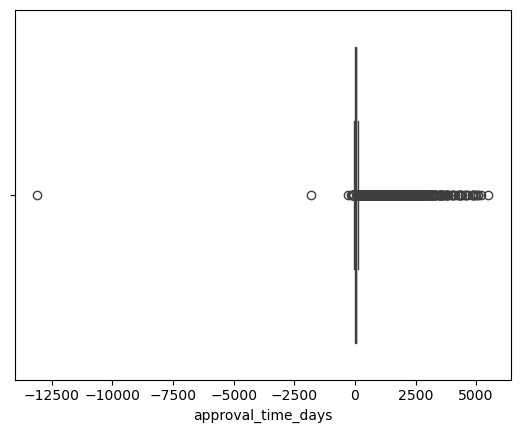

In [ ]:
# Check for outliers in the approval_time column
sns.boxplot(x=df_modern['approval_time_days'])
plt.show()

## 36 · Median Approval Time by Structure Group

Check whether approval times differ systematically across the structure type groups we created. This helps validate whether the grouping captures meaningful variation in the target variable.

In [ ]:
# Check median approval times per structure_type_grouped
median_approval_time = df_modern.groupby('structure_type_grouped')['approval_time_days'].median().reset_index()
print(median_approval_time)

         structure_type_grouped  approval_time_days
0             Commercial_Retail                30.0
1                     Education                33.0
2               Healthcare_Care                35.0
3          Industrial_Warehouse                35.0
4                     Mixed_Use                30.0
5                Office_Medical                26.0
6                 Other_Unknown                23.0
7       Public_Civic_Recreation                33.0
8        Residential_Multi_Unit                33.0
9     Residential_Single_Family                18.0
10  Systems_Alterations_Repairs                33.0
11         Temporary_Structures               133.0
12            Transport_Parking                43.0


/tmp/ipykernel_54601/3681124082.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_approval_time = df_modern.groupby('structure_type_grouped')['approval_time_days'].median().reset_index()


## 37 · Which Structure Groups Have > 1000-Day Approvals?

Identify which structure type groups are responsible for the extreme outliers. The threshold was updated from 365 to **1000 days** in this version to retain more of the long-tail data that is genuine — particularly large commercial and mixed-use developments that legitimately take 2–3 years to approve.

In [ ]:
# Check which structure_type_grouped is related to all the permits with approval times greater than 1000 days and give me a count per structure_type_grouped
long_approval_time = df_modern[df_modern['approval_time_days'] > 1000]
long_approval_time_count = long_approval_time['structure_type_grouped'].value_counts().reset_index()
long_approval_time_count.columns = ['structure_type_grouped', 'count']
print(long_approval_time_count)

         structure_type_grouped  count
0     Residential_Single_Family   1446
1        Residential_Multi_Unit    862
2                     Mixed_Use    236
3                 Other_Unknown    140
4             Transport_Parking     86
5             Commercial_Retail     78
6                Office_Medical     75
7          Industrial_Warehouse     72
8                     Education     33
9       Public_Civic_Recreation     29
10              Healthcare_Care     24
11  Systems_Alterations_Repairs      9
12         Temporary_Structures      1


## 38 · Count of Records with Approval Time < 1000 Days

Before removing outliers, confirm how many records will be retained after the revised cap. This sanity-checks the filtering decision.

In [ ]:
# Check how many columns have approval times less than 1000 days
negative_approval_time = df_modern[df_modern['approval_time_days'] < 1000]
print(f'Number of columns with approval times less than 1000 days: {len(negative_approval_time)}')

Number of columns with approval times less than 1000 days: 596648


## 39 · Remove Out-of-Range Approval Times

Drop rows where `approval_time_days` is:
- `≤ 0` — negative or zero values are data errors (issued before application date)
- `> 1000` — permits beyond ~2.7 years are extreme edge cases unlikely to be representative

The cap was raised from 365 to **1000 days** vs the previous version, preserving more legitimate long-running permits for the model to learn from.

In [ ]:
# Delete all rows with negative and bigger than 1000 approval_time_days values
df_modern = df_modern[(df_modern['approval_time_days'] > 0) & (df_modern['approval_time_days'] <= 1000)]
print(f'Number of rows after removing negative and large approval_time_days values: {len(df_modern)}')

Number of rows after removing negative and large approval_time_days values: 532094


## 40 · Distribution of `approval_time_days`

After cleaning, plot the distribution of the target variable. We expect a right skew — most permits are approved quickly, but a long tail remains even within the 1000-day cap.

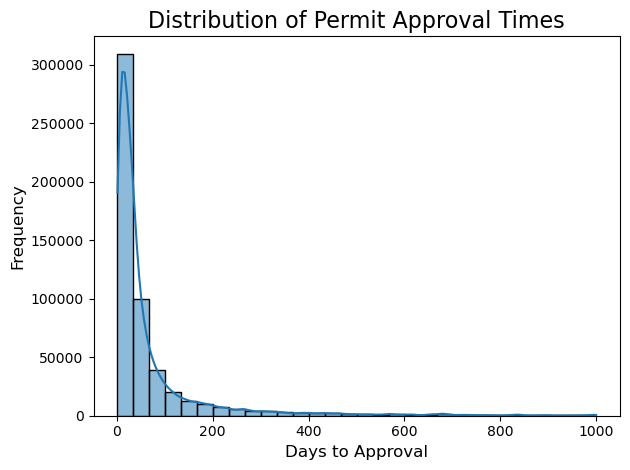

In [ ]:
#Plot the distribution of the approval_time column
sns.histplot(df_modern['approval_time_days'], bins=30, kde=True)
plt.title('Distribution of Permit Approval Times', fontsize=16)
plt.xlabel('Days to Approval', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

## 41 · Seasonal Pattern — Average Approval Time by Quarter

Explore whether approval speed varies by quarter. Summer slowdowns or end-of-year backlogs could appear here.

/tmp/ipykernel_54601/508009357.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Feature')


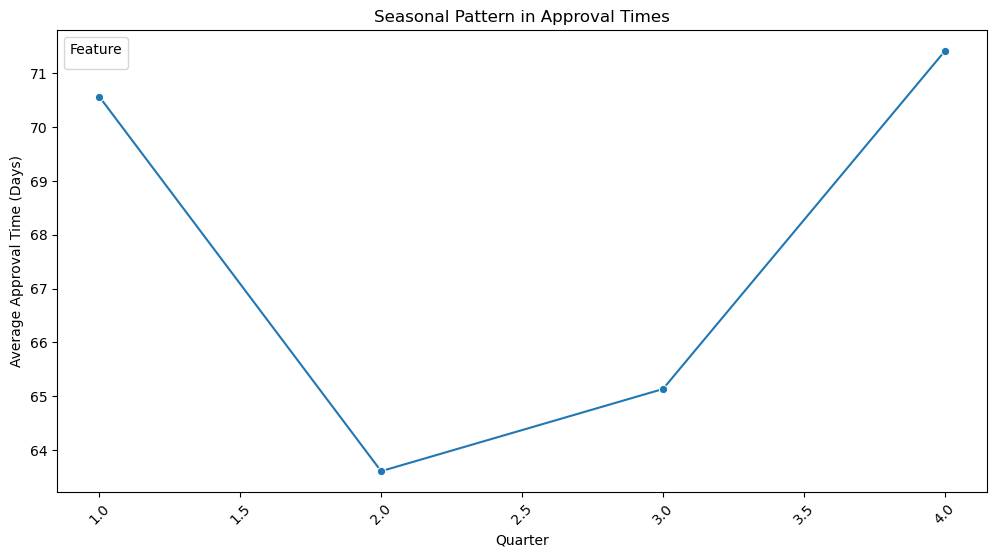

In [ ]:
#Plot for a sesonal pattern in the approval times by plotting the average approval time per quarter and add legend to change the fature names to make it more clear
avg_approval_time_quarter = df_modern.groupby('quarter')['approval_time_days'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_approval_time_quarter, x='quarter', y='approval_time_days', marker='o')
plt.xticks(rotation=45)
plt.xlabel('Quarter')
plt.ylabel('Average Approval Time (Days)')
plt.title('Seasonal Pattern in Approval Times')
plt.legend(title='Feature')

## 42 · Seasonal Pattern — Average Approval Time by Month

A finer-grained view of seasonal effects, broken down by calendar month. Month-level granularity may reveal patterns (e.g. summer slowdown in July–August) that the quarterly view smooths over.

/tmp/ipykernel_54601/1970184570.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_approval_time_quarter = df_modern.groupby('application_month')['approval_time_days'].mean().reset_index()


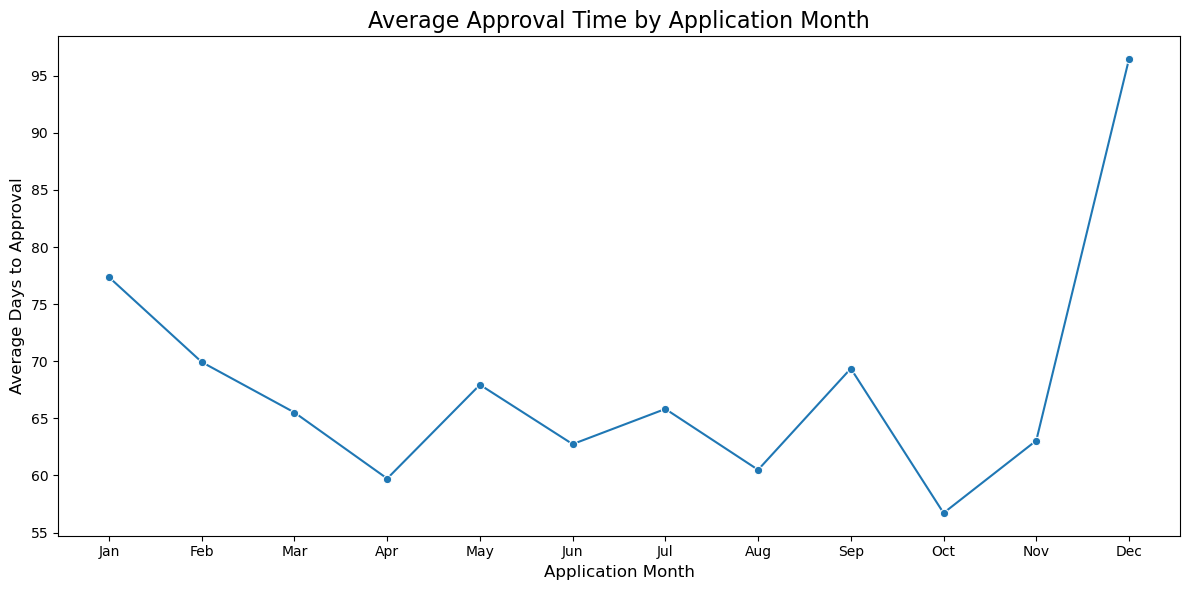

In [ ]:
#Plot for a sesonal pattern in the approval times by plotting the average approval time per quarter and add legend to change the fature names to make it more clear
avg_approval_time_quarter = df_modern.groupby('application_month')['approval_time_days'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_approval_time_quarter, x='application_month', y='approval_time_days', marker='o')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Average Approval Time by Application Month', fontsize=16)
plt.xlabel('Application Month', fontsize=12)
plt.ylabel('Average Days to Approval', fontsize=12)
plt.tight_layout()

## 43 · Application Volume by Year

Check whether application volume has changed over time. A drop in 2024 volume could explain faster approvals in that year (fewer applications = less backlog), rather than any process improvement.

/tmp/ipykernel_54601/3640019505.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_applications_year = df_modern.groupby('application_year').size().reset_index(name='application_count')
/tmp/ipykernel_54601/3640019505.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Feature')


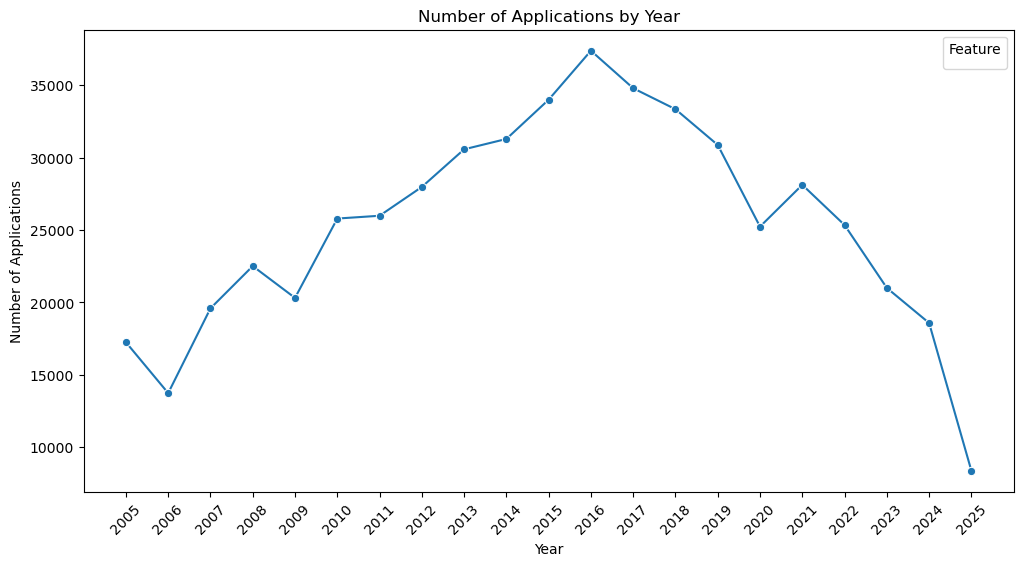

In [ ]:
#Plot the average number of applications per year to check if 2024 is faster because there are less applications
avg_applications_year = df_modern.groupby('application_year').size().reset_index(name='application_count')
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_applications_year, x='application_year', y='application_count', marker='o')
plt.xticks(avg_applications_year['application_year'], rotation=45)
plt.xlabel('Year')
plt.ylabel('Number of Applications')
plt.title('Number of Applications by Year')
plt.legend(title='Feature')

## 44 · Approval Time by Toronto District

Compare the distribution of approval times across the four city districts. South (downtown core) is expected to have the longest times due to the density and complexity of development there. The Y-axis is capped at **1000 days** (updated from 365) to match the new outlier threshold and keep extreme values visible.

/tmp/ipykernel_54601/3087784932.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


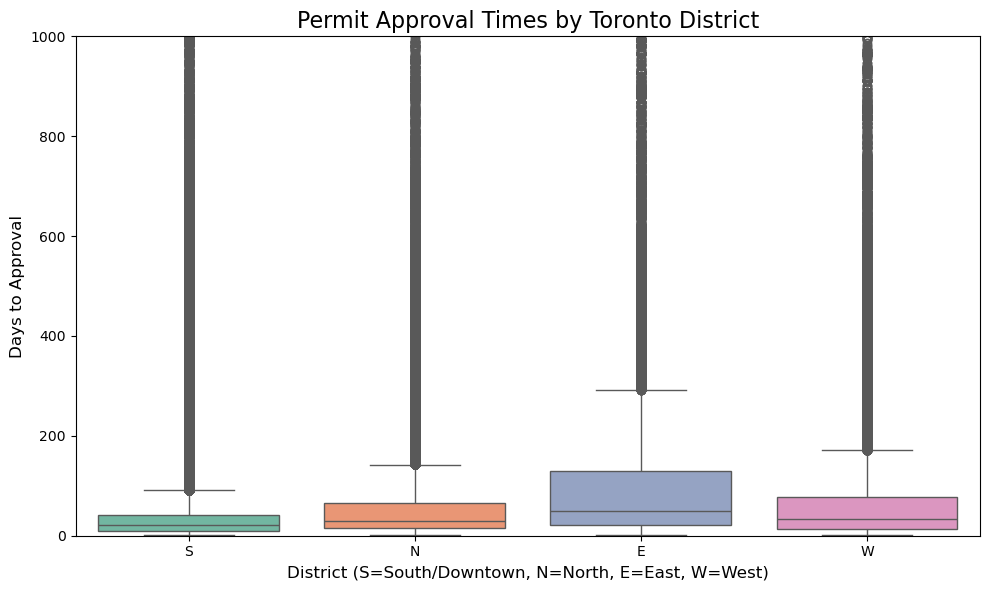

In [ ]:
#Plot the distribution of the approval_time column by district
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_modern, 
    x='district', 
    y='approval_time_days',
    order=['S', 'N', 'E', 'W'], # South first, as it's the downtown core
    palette='Set2'
)

plt.title('Permit Approval Times by Toronto District', fontsize=16)
plt.ylabel('Days to Approval', fontsize=12)
plt.xlabel('District (S=South/Downtown, N=North, E=East, W=West)', fontsize=12)
# Cap the Y-axis so we can actually see the boxes clearly, ignoring the extreme condo outliers
plt.ylim(0, 1000) 
plt.tight_layout()
plt.show()

## 45 · Statistical Testing — ANOVA + Tukey HSD

The boxplot suggests district-level differences. We now test whether those differences are **statistically significant** or just noise.

**Step 1 — One-Way ANOVA:** Tests whether at least one district has a meaningfully different mean approval time. If `p < 0.05` we reject H₀ (that all districts are equal).

**Step 2 — Tukey HSD (if ANOVA rejects H₀):** Post-hoc test that identifies *which specific pairs* of districts differ from each other, while controlling for the multiple comparisons problem.

In [ ]:
# Drop NaNs 
df_test = df_modern.dropna(subset=['approval_time_days', 'district'])

group_S = df_test[df_test['district'] == 'S']['approval_time_days']
group_N = df_test[df_test['district'] == 'N']['approval_time_days']
group_E = df_test[df_test['district'] == 'E']['approval_time_days']
group_W = df_test[df_test['district'] == 'W']['approval_time_days']

# Run ANOVA test to see if there are statistically significant differences in approval times between the districts
f_stat, p_val_anova = stats.f_oneway(group_S, group_N, group_E, group_W)

print("--- ANOVA Results ---")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_val_anova:.4e}")

if p_val_anova < 0.05:
    print("\nConclusion: REJECT the Null Hypothesis.")
    print("There is a statistically significant difference in wait times between districts.")
    print("Running Tukey Test to find exactly which districts differ...\n")
    
    # Run Tukey Test (The "Who is different?" test)
    tukey = pairwise_tukeyhsd(endog=df_test['approval_time_days'],     # Data
                              groups=df_test['district'],                # Groups
                              alpha=0.05)                                # Significance level
    
    print(tukey)
else:
    print("\nConclusion: FAIL TO REJECT the Null Hypothesis.")
    print("Wait times are statistically the same across all districts.")

--- ANOVA Results ---
F-Statistic: 5414.0423
P-Value: 0.0000e+00

Conclusion: REJECT the Null Hypothesis.
There is a statistically significant difference in wait times between districts.
Running Tukey Test to find exactly which districts differ...

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
     E      N -35.1991   0.0  -36.559 -33.8393   True
     E      S -57.2518   0.0 -58.4807  -56.023   True
     E      W -23.3092   0.0 -24.7734  -21.845   True
     N      S -22.0527   0.0 -23.1099 -20.9954   True
     N      W  11.8899   0.0  10.5664  13.2134   True
     S      W  33.9426   0.0  32.7541   35.131   True
-----------------------------------------------------


## 46 · Strict Categorical Formatting for XGBoost

XGBoost with `enable_categorical=True` requires categorical columns to be explicitly typed as `category` dtype at training time. Even though we cast them earlier, the `quarter` column was added after that step — this cell ensures all categoricals are correctly typed immediately before defining features and splitting the data.

In [ ]:
# STRICT Categorical Formatting for LightGBM
categorical_features = [
    'permit_type', 'structure_type_grouped', 'postal', 
    'application_month', 'application_year', 'use_change', 
    'district', 'quarter'
]

for col in categorical_features:
    if col in df_modern.columns:
        df_modern[col] = df_modern[col].astype('category')

# Verify the types are correct
print("Data Types Check (Categoricals should say 'category'):")
print(df_modern[categorical_features].dtypes)

Data Types Check (Categoricals should say 'category'):
permit_type               category
structure_type_grouped    category
postal                    category
application_month         category
application_year          category
use_change                category
district                  category
quarter                   category
dtype: object


## 47 · Model Prep, `PredefinedSplit` & XGBoost Tuning

**v2 change — model:** LightGBM has been replaced with **XGBoost** (`tree_method='hist'`, `enable_categorical=True`) to explore whether a different boosting implementation produces better generalisation on this dataset.

**v2 change — cross-validation fix with `PredefinedSplit`:** The previous version used standard k-fold CV inside `RandomizedSearchCV`, which randomly reassigned train/val rows on each fold. This caused data leakage — some rows the model was "validated" on during search had already appeared in training. `PredefinedSplit` fixes this by creating a single fixed fold:
- `test_fold = -1` → always treated as training data
- `test_fold = 0` → always treated as validation data

The search is then run on the combined `X_search` dataset, but the fold is locked — the same rows are always in train and always in val, eliminating leakage.

**Early stopping** still monitors the dedicated val set during each estimator fit, so the model stops before it overfits on that fold.

**Evaluation report:** Metrics are computed on all three original splits (train/val/test). Feature importance is plotted using XGBoost's native `plot_importance` with `type='weight'`.


Starting hyperparameter tuning on 425675 permits...
Fitting 1 folds for each of 15 candidates, totalling 15 fits

Best Parameters Found:
{'subsample': 0.8, 'n_estimators': 800, 'min_child_weight': 100, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.8}

       MODEL RISK GENERALIZATION REPORT
Metric     | Train (60%)  | Val (20%)    | Test (20%)  
--------------------------------------------------
MAE        | 35.78        | 35.68        | 38.51       
RMSE       | 67.23        | 67.45        | 73.66       
R² Score   | 0.683        | 0.687        | 0.616       

✅ Status: Model is robust and generalizing perfectly to unseen data!


<Figure size 1000x600 with 0 Axes>

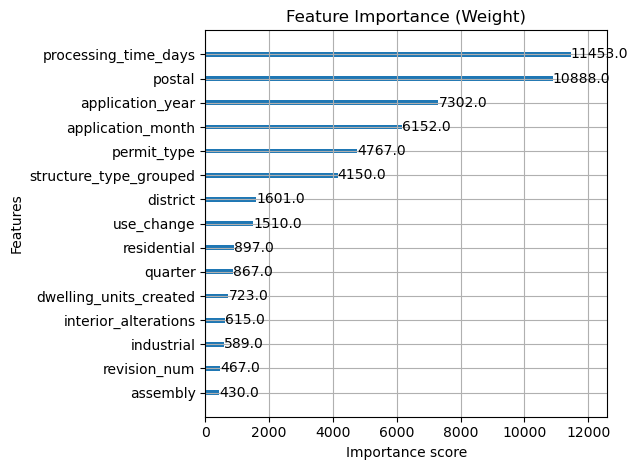

In [ ]:
from sklearn.model_selection import PredefinedSplit

# 1. Define Features (X) and Target (y)
X = df_modern.drop(columns=['permit_num', 'project_id', 'geo_id', 'approval_time_days', 'permit_suffix']) 
y = df_modern['approval_time_days'] 

for col in X.select_dtypes(include=['object', 'string']).columns:
    X[col] = X[col].astype('category')

# 2. The 3-Way Split (The logic remains, but we combine Train/Val for the Search)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# --- NEW: Create the PredefinedSplit ---
# We combine X_train and X_val into one "search" dataset.
# test_fold array: -1 for training indices, 0 for validation indices.
X_search = pd.concat([X_train, X_val])
y_search = pd.concat([y_train, y_val])

test_fold = np.concatenate([
    -1 * np.ones(X_train.shape[0]), # -1 means "use for training"
     0 * np.ones(X_val.shape[0])    #  0 means "use for validation"
])
ps = PredefinedSplit(test_fold)
# ---------------------------------------

# 3. Initialize the base XGBoost Regressor
xgb_base = xgb.XGBRegressor(
    tree_method='hist',          
    enable_categorical=True,     
    device='cpu',               
    n_jobs=1,                    # Keep at 1 because RandomizedSearchCV uses 8
    max_bin=256,                  
    early_stopping_rounds=50,
    eval_metric='mae'
)

# 4. Define the Grid (Safely increased n_estimators due to early stopping)
param_grid = {
    'max_depth': [4, 5, 7],                  
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [500, 800,1000],  # Increased ceiling for better accuracy
    'min_child_weight': [50, 100, 200],       
    'subsample': [0.8, 1.0],  
    'gamma': [0.1, 0.5, 1],  
    'colsample_bytree': [0.7, 0.8]  
}

# 5. Randomized Grid Search
print(f"\nStarting hyperparameter tuning on {X_search.shape[0]} permits...")
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=15,        
    scoring='neg_mean_absolute_error',
    cv=ps,                           # <-- CHANGED: Uses our 1-fold fixed split
    verbose=1,
    random_state=42,
    n_jobs=-1                         
)

# Use X_search and y_search here
random_search.fit(
    X_search, y_search,
    eval_set=[(X_val, y_val)],       # Early stopping still monitors the Val set
    verbose=False
)

best_model = random_search.best_estimator_
print(f"\nBest Parameters Found:\n{random_search.best_params_}")

# 6. Generate predictions (using original splits for the report)
preds_train = best_model.predict(X_train)
preds_val = best_model.predict(X_val)
preds_test = best_model.predict(X_test)

# 7. Calculate Metrics
mae_train = mean_absolute_error(y_train, preds_train)
mae_val = mean_absolute_error(y_val, preds_val)
mae_test = mean_absolute_error(y_test, preds_test)

rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
rmse_val = np.sqrt(mean_squared_error(y_val, preds_val))
rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))

r2_train = r2_score(y_train, preds_train)
r2_val = r2_score(y_val, preds_val)
r2_test = r2_score(y_test, preds_test)

# 8. Print the generalized report
print("\n" + "="*50)
print("       MODEL RISK GENERALIZATION REPORT")
print("="*50)

print(f"{'Metric':<10} | {'Train (60%)':<12} | {'Val (20%)':<12} | {'Test (20%)':<12}")
print("-" * 50)
print(f"{'MAE':<10} | {mae_train:<12.2f} | {mae_val:<12.2f} | {mae_test:<12.2f}")
print(f"{'RMSE':<10} | {rmse_train:<12.2f} | {rmse_val:<12.2f} | {rmse_test:<12.2f}")
print(f"{'R² Score':<10} | {r2_train:<12.3f} | {r2_val:<12.3f} | {r2_test:<12.3f}")
print("=" * 50)

# Automated Logic Check based on MAE
if (mae_test - mae_train) > 5.0: 
    print("\n⚠️ Warning: Potential Overfitting Detected. Model performs noticeably worse on unseen data.")
elif mae_train > 45.0: 
    print("\n⚠️ Warning: Potential Underfitting Detected. Baseline error is high across all sets.")
else:
    print("\n✅ Status: Model is robust and generalizing perfectly to unseen data!")

# 9. Plot Feature Importance natively with XGBoost
plt.figure(figsize=(10, 6))
xgb.plot_importance(
    best_model, 
    max_num_features=15, 
    importance_type='weight', 
    title='Feature Importance (Weight)'
)
plt.tight_layout()
plt.show()

## 48 · Presentation Plot — Median Approval Time by Permit Type

A polished horizontal bar chart showing the median days to approval for each permit type. Sorted descending so the slowest permit types are immediately visible. Annotated with the exact day count on each bar.

/tmp/ipykernel_54601/2833513741.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_times = df_modern.groupby('permit_type')['approval_time_days'].median().sort_values(ascending=False).reset_index()
/tmp/ipykernel_54601/2833513741.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='approval_time_days', y='permit_type', data=median_times, palette='Blues_r')


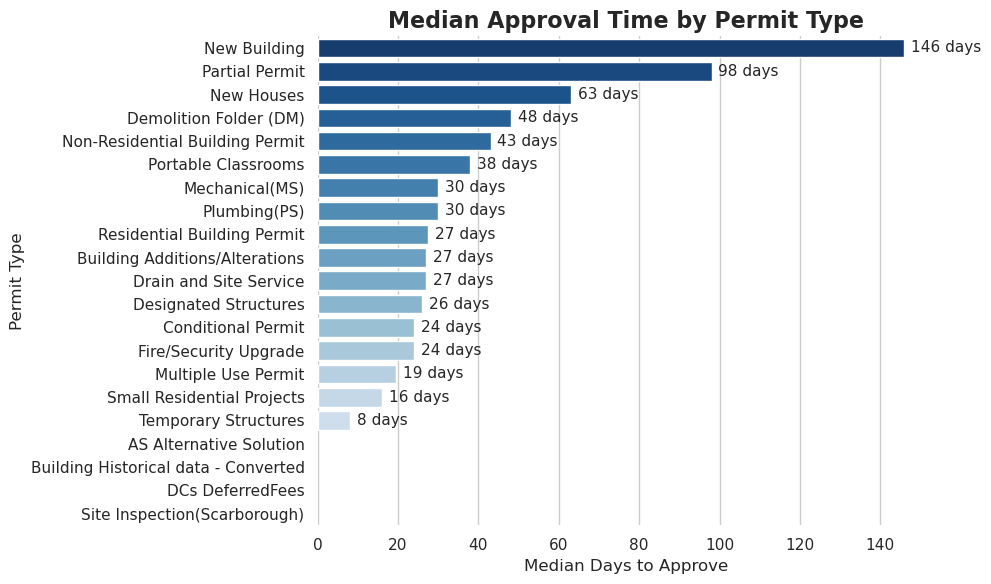

In [ ]:


# Calculate medians
median_times = df_modern.groupby('permit_type')['approval_time_days'].median().sort_values(ascending=False).reset_index()

# Clean up the labels for the presentation
median_times['permit_type'] = median_times['permit_type'].str.replace('_', ' ')

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x='approval_time_days', y='permit_type', data=median_times, palette='Blues_r')

plt.title('Median Approval Time by Permit Type', fontsize=16, fontweight='bold')
plt.xlabel('Median Days to Approve', fontsize=12)
plt.ylabel('Permit Type', fontsize=12)

# Add the numbers on the bars
for p in ax.patches:
    ax.annotate(f"{int(p.get_width())} days", 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## 49 · Presentation Plot — Long-Tail Distribution

A histogram with KDE showing the full shape of the approval time distribution within the 1000-day cap. The red dashed line marks the median. This chart illustrates the 'long tail' — most permits are approved quickly, but a meaningful minority take significantly longer, pulling the mean well above the median.

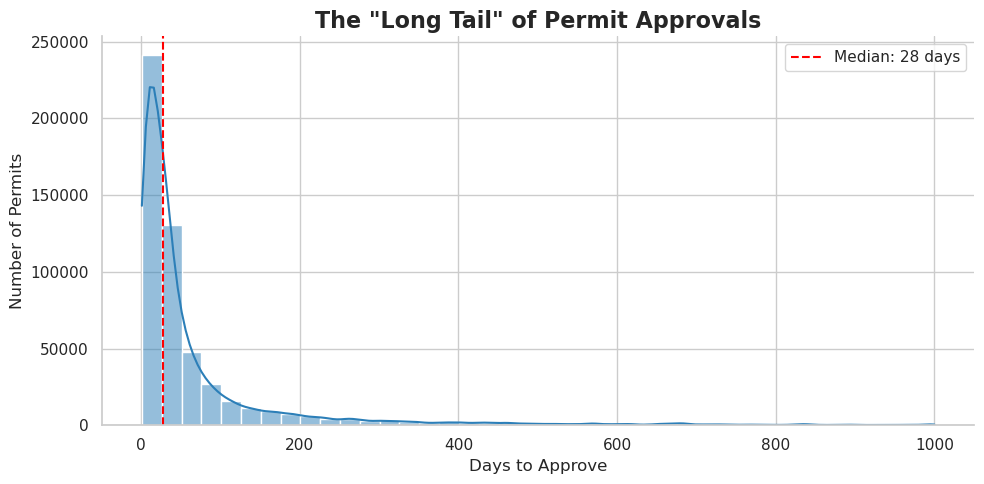

In [ ]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Plot a distribution of approval times (zoomed in to 0-1000 days for readability)
sns.histplot(df_modern[df_modern['approval_time_days'] <= 1000]['approval_time_days'], 
             bins=40, color='#2c7fb8', kde=True)

plt.title('The "Long Tail" of Permit Approvals', fontsize=16, fontweight='bold')
plt.xlabel('Days to Approve', fontsize=12)
plt.ylabel('Number of Permits', fontsize=12)
plt.axvline(df_modern['approval_time_days'].median(), color='red', linestyle='--', label=f"Median: {int(df_modern['approval_time_days'].median())} days")

plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
#Checkpoint, save the combined dataset to a new CSV file
df_permits.to_csv('data/permits_combined.csv', index=False)